# Pseudo EOF patterns based on GMM - Full Monthly Data (No DJF Selection)

In [1]:
import os
from importlib import reload
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy as ctp
import seaborn as sns
from sklearn import mixture, decomposition
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import xesmf as xe

In [2]:
import preproc
import utils
import utenso
import eof
import utdata
import utstats
import metric
import geoplot as gpl
plt.style.use("/home/gsato/latgmm/paper.mplstyle")

In [3]:
ds_pi = xr.open_dataset("/groups/XDU5/Go/research_data/latgmm/sst_pi_500.nc", decode_timedelta=True)
ds_mh = xr.open_dataset("/groups/XDU5/Go/research_data/latgmm/sst_mh_500.nc", decode_timedelta=True)

### 1. Interpolate data on a curvilinear grid to a rectilinear grid

In [4]:
def regrid(ds):
    
    dr = ds
    
    #1 rename the coordinate names to lon and lat because xESMF has no way to guess variable meaning
    ds = ds.rename({"TLONG": "lon", "TLAT": "lat"})

    #2 regrid it to a global 1deg * 1deg grid 
    ds_out = xr.Dataset(
    {
        "lat": (["lat"], np.arange(-90, 90, 1.0), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(-180, 180, 1.0), {"units": "degrees_east"}),
    }
    )

    #3 Regridding
    regridder = xe.Regridder(ds, ds_out, "bilinear")
    dr_out = regridder(dr)
    
    return dr_out

In [5]:
temp_pi_reg = regrid(ds_pi)
temp_mh_reg = regrid(ds_mh)

In [6]:
# selecting the surface layer and the last 200 years

#sst_pi = temp_pi_reg.sel(z_t = 500.0) #selecting depth
sst_pi_200 = temp_pi_reg.sel(time=slice("0701-01-01 00:00:00", "0900-12-01 00:00:00")) 
#sst_mh = temp_mh_reg.sel(z_t = 500.0)
sst_mh_200 = temp_mh_reg.sel(time=slice("0701-01-01 00:00:00", "0900-12-01 00:00:00")) 
sst_pi_200 = sst_pi_200["sst"]
sst_mh_200 = sst_mh_200["sst"]

In [7]:
# getting climatologies and anomalies

sst_pi_clim = sst_pi_200.groupby('time.month').mean("time")
sst_pi_anom = sst_pi_200.groupby('time.month')-sst_pi_clim

sst_mh_clim = sst_mh_200.groupby('time.month').mean("time")
sst_mh_anom = sst_mh_200.groupby('time.month')-sst_mh_clim

In [8]:
# 6ka has more nan values => more land grid points
print(sst_pi_anom[0,:,:].isnull().sum())
print(sst_mh_anom[0,:,:].isnull().sum())

<xarray.DataArray 'sst' ()> Size: 8B
array(19717)
Coordinates:
    z_t      float32 4B 500.0
    time     object 8B 0701-01-01 00:00:00
    month    int64 8B 1
<xarray.DataArray 'sst' ()> Size: 8B
array(19778)
Coordinates:
    z_t      float32 4B 500.0
    time     object 8B 0701-01-01 00:00:00
    month    int64 8B 1


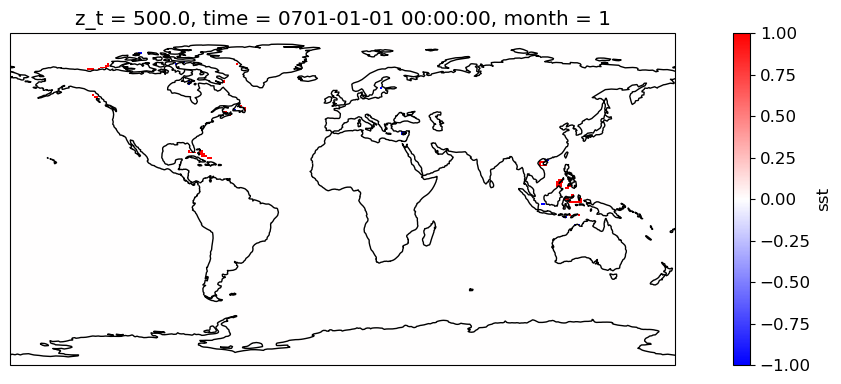

In [9]:
#check the difference in the land-sea mask 
plt.figure(figsize=(12, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
pi_mask = xr.where(sst_pi_anom[0,:,:].isnull(), 0, 1) # sea =>1, nan(land) => 0
mh_mask = xr.where(sst_mh_anom[0,:,:].isnull(), 0, 1)
(pi_mask-mh_mask).plot.pcolormesh(ax=ax, x="lon", y="lat", cmap="bwr")
ax.coastlines()

In [10]:
#making a new dataset

sst_pi_anom = xr.Dataset(
    {
        'ssta': (["time", 'lat', 'lon'], sst_pi_anom[:,:,:].values),
    },
    coords={"time": sst_pi_anom["time"],
        'lat': sst_pi_anom["lat"],   # Latitude coordinates
        'lon': sst_pi_anom["lon"],  # Longitude coordinates
    },
)

sst_mh_anom = xr.Dataset(
    {
        'ssta': (["time", 'lat', 'lon'], sst_mh_anom[:,:,:].values),
    },
    coords={"time": sst_pi_anom["time"],
        'lat': sst_pi_anom["lat"],   # Latitude coordinates
        'lon': sst_pi_anom["lon"],  # Longitude coordinates
    },
)

In [11]:
sst_pi_anom.drop_vars(["z_t"])
sst_mh_anom.drop_vars(["z_t"])

<xarray.Dataset> Size: 622MB
Dimensions:  (time: 2400, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 19kB 0701-01-01 00:00:00 ... 0900-12-01 00:00:00
    month    (time) int64 19kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 177.0 178.0 179.0
Data variables:
    ssta     (time, lat, lon) float32 622MB 0.0 0.0 0.0 ... -0.008574 -0.008546

### 2. Mask out the ocean

In [12]:
#select ocean grid points for both 6ka and pi 
sst_mh_anom_masked = sst_mh_anom.where((pi_mask==1) & (mh_mask==1))
sst_pi_anom_masked = sst_pi_anom.where((pi_mask==1) & (mh_mask==1))

### 4. Sort longitude to 0->180->0 & latitude weight

In [13]:
pi_for_concat = sst_pi_anom_masked
ds_east_pi = pi_for_concat.sel(lon=slice(130, 179))
ds_west_pi = pi_for_concat.sel(lon=slice(-180, -70))
ds_selected_pi = xr.concat([ds_east_pi, ds_west_pi], dim="lon")
ds_selected_pi

<xarray.Dataset> Size: 278MB
Dimensions:  (time: 2400, lat: 180, lon: 161)
Coordinates:
    z_t      (time) float32 10kB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
  * time     (time) object 19kB 0701-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 1kB 130.0 131.0 132.0 133.0 ... -72.0 -71.0 -70.0
Data variables:
    ssta     (time, lat, lon) float32 278MB 0.0 0.0 0.0 ... 0.002189 0.002244

In [14]:
mh_for_concat = sst_mh_anom_masked
ds_east_mh = mh_for_concat.sel(lon=slice(130, 179))
ds_west_mh = mh_for_concat.sel(lon=slice(-180, -70))
ds_selected_mh = xr.concat([ds_east_mh, ds_west_mh], dim="lon")
ds_selected_mh

<xarray.Dataset> Size: 278MB
Dimensions:  (time: 2400, lat: 180, lon: 161)
Coordinates:
    z_t      (time) float32 10kB 500.0 500.0 500.0 500.0 ... 500.0 500.0 500.0
  * time     (time) object 19kB 0701-01-01 00:00:00 ... 0900-12-01 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float64 1kB 130.0 131.0 132.0 133.0 ... -72.0 -71.0 -70.0
Data variables:
    ssta     (time, lat, lon) float32 278MB 0.0 0.0 0.0 ... -0.007366 -0.007395

In [15]:
# Gulf of Mexico & Caribbean Sea region upper and lower parts
gulf_lon_min, gulf_lon_max = -96, -70
gulf_lat_min, gulf_lat_max = 16, 30
caribbean_lon_min, caribbean_lon_max = -83, -70
caribbean_lat_min, caribbean_lat_max = 10, 16

# Create a mask for the region (True where ocean, False elsewhere)
gulf_mask = (
    (ds_selected_pi['lon'] >= gulf_lon_min) & 
    (ds_selected_pi['lon'] <= gulf_lon_max) &
    (ds_selected_pi['lat'] >= gulf_lat_min) & 
    (ds_selected_pi['lat'] <= gulf_lat_max)
)
caribbean_mask = (
    (ds_selected_pi['lon'] >= caribbean_lon_min) & 
    (ds_selected_pi['lon'] <= caribbean_lon_max) &
    (ds_selected_pi['lat'] >= caribbean_lat_min) & 
    (ds_selected_pi['lat'] <= caribbean_lat_max)
)

# Mask out the Gulf of Mexico and Caribbean by setting those values to NaN
ds_selected_pi_masked = ds_selected_pi.where(~gulf_mask)
ds_selected_mh_masked = ds_selected_mh.where(~gulf_mask)
ds_selected_pi_masked = ds_selected_pi_masked.where(~caribbean_mask)
ds_selected_mh_masked = ds_selected_mh_masked.where(~caribbean_mask)

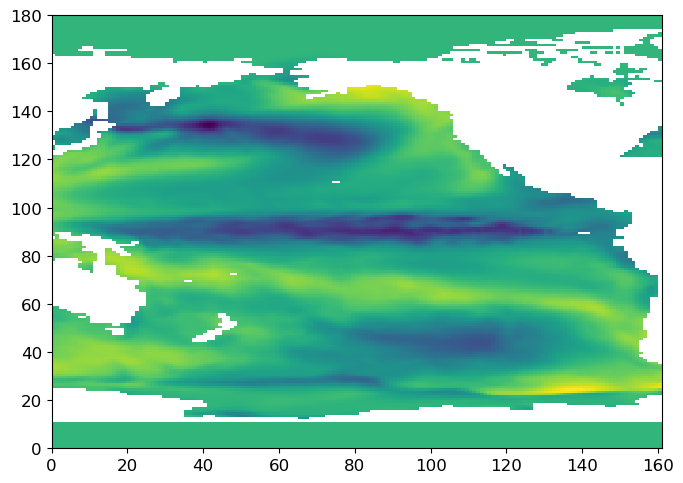

In [16]:
# check if the masking worked correctly by plotting the first time slice of the masked dataset
plt.pcolormesh(ds_selected_pi_masked["ssta"][0,:,:])

In [17]:
# weight the SSTA by latitudes

def weight_sst_anomalies(data):
    """
    Applies latitude-based weighting to SST anomalies using the square root of the cosine of latitude.

    Parameters:
    - sst_anomalies (numpy array): 2D or 3D array of SST anomalies (time, lat, lon).
    - latitudes (numpy array): 1D array of latitudes corresponding to SST data.

    Returns:
    - weighted_sst (numpy array): SST anomalies weighted by sqrt(cos(latitude)).
    """
    # Convert latitudes to radians
    lat_radians = np.deg2rad(data["lat"].values)
    
    # Compute the weighting factor (sqrt(cos(lat)))
    weights = np.sqrt(np.cos(lat_radians))
    
    # Expand dimensions to match SST anomaly array (for broadca
    weight_matrix = xr.DataArray(weights,dims=["lat"])
    
    weighted_sst = data *weight_matrix

    return weighted_sst

sst_pi_anom_sorted_weighted = weight_sst_anomalies(ds_selected_pi_masked) #sst_pi_anom_sorted
sst_mh_anom_sorted_weighted = weight_sst_anomalies(ds_selected_mh_masked) #sst_mh_anom_sorted

### 5. Project 6ka SSTA onto PCs from piControl

In [18]:
def project_sst_to_eofs(data1,data2,pc_components):
    ##################################################################
    # This is the function to project data2 onto EOFs obtained from data1
    # data1 and data2 should have variables called ssta
    # pc_components: the number of PCs to be used for the projection 
    ##################################################################
    import numpy as np
    from numpy import linalg as LA
    from sklearn.decomposition import PCA
    ##################################################################
    
    ds4eof_pi = data1
    #idx_notNaN_pi = np.ma.masked_invalid(ds4eof_pi["ssta"]).filled(0.) # replace NaN values with 0
    #idx_notNaN_pi = (idx_notNaN_pi - idx_notNaN_pi.mean())/idx_notNaN_pi.std() # standardize the anomalies
    #nt, ny, nx = idx_notNaN_pi.shape
    #X_pi = np.reshape(idx_notNaN_pi, (nt, ny*nx))            # reduce 3-D to 2-D
    #X_pi_mean = X_pi.mean(axis=0)                         # Mean over all timesteps
    #C_pi = np.cov(X_pi, rowvar=False)                     # calculate covariance matrix
    #eigenvalues_pi, eigenvectors_pi=LA.eig(C_pi)          # get eigenvalues and eigenvectors
    #idx = eigenvalues_pi.argsort()[::-1]                  # Sorts the indices of the matrix 
    #eigenvectors_pi = eigenvectors_pi[:,idx]                # based on the magnitudes of the eigenvalues
    #eigenvectors_pi[:,1] = -eigenvectors_pi[:,1]
    #PC_pi = np.dot(X_pi - X_pi_mean, eigenvectors_pi[:,0:pc_components])   # the number of PCs should be identical for PC and 6ka
    sppca = eof.SpatioTemporalPCA(ds4eof_pi, n_components=pc_components)
    ##################################################################

    ds4eof_mh = data2
    #idx_notNaN_mh = np.ma.masked_invalid(ds4eof_mh["ssta"]).filled(0.)
    #idx_notNaN_mh = (idx_notNaN_mh - idx_notNaN_mh.mean())/idx_notNaN_mh.std() # standardize the anomalies
    #nt_, ny_, nx_ = idx_notNaN_mh.shape
    #X_mh = np.reshape(idx_notNaN_mh, (nt_, ny_*nx_))
    #X_mh_centered = np.empty(shape=(len(X_mh[:,0]), len(X_mh[0,:])), dtype=np.float64)
    #X_mh_centered = np.where(X_mh != 0, X_mh - X_pi_mean, 0)
    
    return sppca, sppca.transform(ds4eof_mh)
    #PC_mh = np.dot(X_mh_centered, eigenvectors_pi[:,0:pc_components])        
    # PCs in piControl and pseudo-PCs in 6ka  
    #PC_mh = X_mh・eigenvectors_pi
    #return PC_pi, PC_mh

In [37]:
PC_pi, PC_mh = project_sst_to_eofs(sst_pi_anom_sorted_weighted.sel(lat=slice(-30,30)),
                                   sst_mh_anom_sorted_weighted.sel(lat=slice(-30,30)),
                                   4)

In [38]:
print(PC_pi.get_principal_components().shape)
print(PC_pi.explained_variance())
print(np.sum(PC_pi.explained_variance()))

(2400, 4)
[0.54124654 0.12414744 0.05610165 0.03224346]
0.7537390812795528


### 6. Make PCs data

In [39]:
PC_pi_st = PC_pi.get_principal_components()
PC_mh_st = xr.DataArray(PC_mh,
    dims=["time", "eof"],
    coords={"time": PC_pi_st["time"], "eof": PC_pi_st["eof"]},
)

### 7. Get ENSO events

In [40]:
def add_member(data):

    data_return = data.assign_coords(
        member=('time', len(sst_pi_anom_sorted_weighted['time']) * ["piControl"]))

    return data_return

x_enso = add_member(sst_pi_anom_sorted_weighted)
x_events = add_member(sst_pi_anom_sorted_weighted)

x_enso_mh = add_member(sst_pi_anom_sorted_weighted)
x_events_mh = add_member(sst_pi_anom_sorted_weighted)

In [41]:
# piControl

pcgmm_storer = {}

z_enso_da = PC_pi_st.sel(time=x_enso.time)

# Group by DJF season-year and take the mean
z_events_da = z_enso_da.groupby('time.month').mean("time")

pcgmm_storer["iCESM"] = dict(
        z_enso=z_enso_da,
        z_events=z_events_da,)

In [42]:
# 6ka
z_enso_da_mh = PC_mh_st.sel(time=x_enso_mh.time)

# Group by DJF season-year and take the mean
z_events_da_mh = z_enso_da.groupby('time.month').mean("time")

pcgmm_storer["iCESM_6ka"] = dict(
        z_enso=z_enso_da_mh,
        z_events=z_events_da_mh,)

### 8. GMM scan

In [43]:
eof_projections = ["iCESM", "iCESM_6ka"]
n_classes = np.arange(2, 9, 1)
n_runs = 250 # the number of runs for each combination of covariance type and number of classes
z_enso = pcgmm_storer["iCESM"]['z_enso']
cov_types = ["spherical", "tied", "diag", "full"]
base_seed = 42
result = []

for cov in cov_types:
    for k in n_classes:
        for r in range(n_runs):
            gmm = mixture.GaussianMixture(
                n_components=k,
                covariance_type=cov,
                n_init=1,                 # one init per outer run
                random_state=base_seed + r,
                max_iter=100 # the maximum number of iterations for the EM algorithm
            )
            gmm.fit(z_enso.data)
            result.append({
                "covariance_type": cov,
                "k": k,
                "run": r,
                "bic": gmm.bic(z_enso.data), #"aic": gmm.aic(z_enso.data),
                "gmm": gmm
            })

pcgmm_storer["iCESM"]['gmm_scan'] = pd.DataFrame(result)

In [99]:
def bic(gmm, X, n_additional_parameters=0):
    """ Bayesian Information Criterion for GMMs including additional parameters.

    Args: 
        gmm (sklearn.mixture.GaussianMixture): The GMM to compute the BIC for.
        X (np.ndarray): The input samples of shape (n_samples, n_dimensions).
    
    Returns:
        bic (float) : The lower the better.
    """
    n_parameters = gmm._n_parameters() + n_additional_parameters
    return -2 * gmm.score(X) * X.shape[0] + n_parameters * np.log(X.shape[0])

eof_projections = ["iCESM", "iCESM_6ka"]
n_classes = np.arange(2, 9, 1)
n_runs = 250
z_enso = pcgmm_storer["iCESM"]['z_enso']
result = []
for k in n_classes:
    for r in range(n_runs):
        gmm = mixture.GaussianMixture(n_components=k, 
                                      covariance_type='full', max_iter=n_runs)
        gmm.fit(z_enso.data)
        result.append(
            {'k': k, 'bic': bic(gmm, z_enso.data, n_additional_parameters=0), 'gmm': gmm}
        )
pcgmm_storer["iCESM"]['gmm_scan'] = pd.DataFrame(result)

### 9. Store probability memberships

In [44]:
# piControl

gmm_scan = pcgmm_storer['iCESM']['gmm_scan'] 
gmm = gmm_scan.loc[gmm_scan['bic'].idxmin()]['gmm']
#f = gmm_scan.loc[gmm_scan['k'] == 4]
#gmm = f.loc[f["bic"].idxmin()]["gmm"]
gmm_order = np.argsort(gmm.means_[:, 0])[::-1]

z_enso = pcgmm_storer['iCESM']['z_enso']
z_events = pcgmm_storer['iCESM']['z_events']
# Event weights
p_c_given_x = utenso.posterior_weights(
    z_enso.data, means=gmm.means_, covariances=gmm.covariances_,
    prior_weights=gmm.weights_
)
# convert to xarray
p_c_given_x_da = xr.DataArray(data=p_c_given_x, dims=['time', 'classes'], 
                              coords={ 
                                'time': np.array(z_enso['time'].data), #dtype='datetime64[M]'),
                                'member': ('time', z_enso['member'].data),
                                'classes': np.arange(p_c_given_x.shape[1]) + 1
                              },
                              attrs={'gmm_sort': gmm_order})

In [45]:
# 6ka

# Project the 6ka SST data onto the trained GMM by piControl data

# Soft assignments (posterior probabilities)
X_test_pca = pcgmm_storer["iCESM_6ka"]['z_enso'].data
responsibilities = gmm.predict_proba(X_test_pca)  # Shape (n_samples, n_components)

# Compute the expected mean for the second dataset
expected_means = np.dot(responsibilities.T, X_test_pca) / responsibilities.sum(axis=0)[:, None]

expected_covariances = np.zeros_like(gmm.covariances_)

# Compute the expected covariances for the second dataset
for k in range(gmm.n_components):
    X_centered = X_test_pca - expected_means[k]
    gamma_k = responsibilities[:, k][:, np.newaxis]  # Expand dims for broadcasting
    expected_covariances[k] = (gamma_k * X_centered).T @ X_centered / gamma_k.sum()
    
# Compute the expected weights for the second dataset
expected_weights = responsibilities.mean(axis=0)  # Shape (n_components,)
    
gmm_order_mh = np.argsort(expected_means[:, 0])[::-1]
    
z_enso_mh = pcgmm_storer['iCESM_6ka']['z_enso']
z_events_mh = pcgmm_storer['iCESM_6ka']['z_events']

# Event weights
p_c_given_x_mh = utenso.posterior_weights(
    z_enso_mh.data, means=expected_means, covariances=expected_covariances,
    prior_weights=expected_weights
)
# convert to xarray
p_c_given_x_da_mh = xr.DataArray(data=p_c_given_x_mh, dims=['time', 'classes'], 
                              coords={ 
                                'time': np.array(z_enso_mh['time'].data), #dtype='datetime64[M]'),
                                'member': ('time', z_enso_mh['member'].data),
                                'classes': np.arange(p_c_given_x_mh.shape[1]) + 1
                              },
                              attrs={'gmm_sort': gmm_order_mh})

### 10. Spatial patterns

In [52]:
def plot_gaussians(gmm, ax, gmm_order=None, 
                   gmclrs=['maroon', 'darkorange', 'gold', 'lightblue', 'darkblue', 'black', 
                   'darkgreen', 'magenta'],
                   alpha=0.5):
    """ Plot the Gaussian components of a Gaussian Mixture Model.
    """
    class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña', 
    "", "", "", ""]
    
    if gmm_order is None:
        gmm_order = np.arange(gmm.n_components)

    for i, k in enumerate(gmm_order):
        mean = gmm.means_[k, :]
        if gmm.covariance_type == "full":
            Sigma = gmm.covariances_[k, :]
        elif gmm.covariance_type == "diag":
            Sigma = np.diag(gmm.covariances_[k, :])

        gmkwargs= dict(fill=False)
        if gmclrs is not None:
            gmkwargs['edgecolor'] = 'k' #gmclrs[i] 
            gmkwargs['facecolor'] = gmclrs[i] 
            gmkwargs['fill'] = True
            gmkwargs['alpha'] = alpha

        for p in [0.7, 0.4, 0.1]:
            if p==0.1:
                gmkwargs['label'] = class_names[i]#rf"$c_{k}$"
            gpl.plot_2dgaussian(mean, Sigma,
                                 ax=ax, p=p, **gmkwargs)
    return ax

### 11. BIC and Latent space

Text(0.5, 1.0, 'BIC')

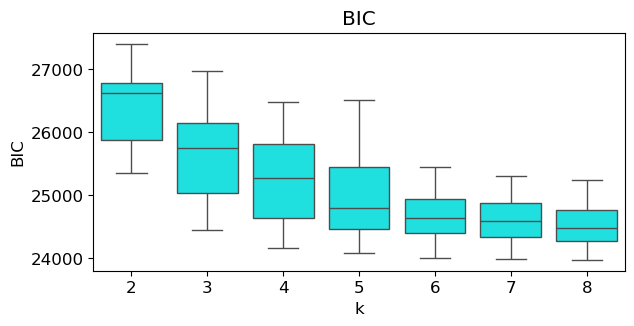

In [47]:
reload(gpl)
n_clusters = 6 

nrows, ncols = (n_clusters-3, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
#height_ratio[1] = 1
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

# Plot BIC
idx = 0 #n + 1  
ax = fig.add_subplot(gs[idx,0])
axs[idx,0] = ax
ax = sns.boxplot(data=pcgmm_storer["iCESM"]['gmm_scan'], x='k', y='bic', ax=ax,
                 color='cyan', fliersize=0.5)
ax.set_ylabel("BIC")
ax.set_title("BIC")
#plt.savefig("/home/gsato/latgmm/figures/BIC_200_SST_monthly.pdf")

array([<Axes: title={'center': 'piControl'}, xlabel='PC1', ylabel='PC2'>,
       <Axes: title={'center': '6ka'}, xlabel='PC1', ylabel='PC2'>, None,
       None, None, None], dtype=object)

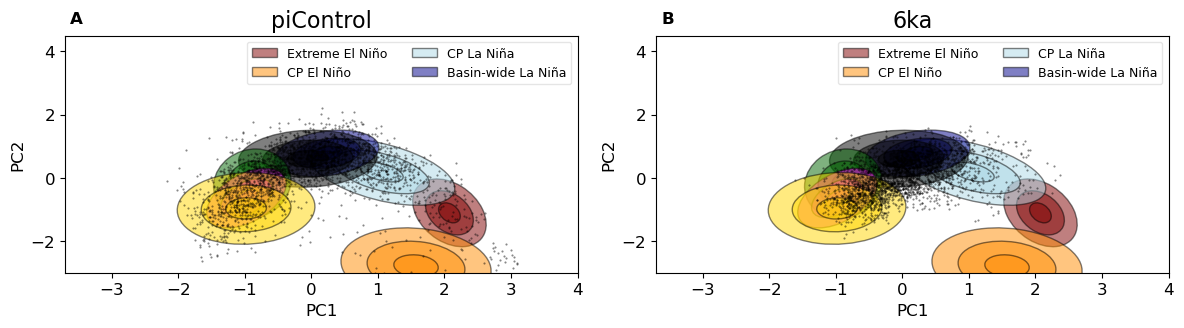

In [53]:
reload(gpl)
#storer = pcgmm_storer[projection]
n_clusters = 6 
#np.max([
#    storer['gmm_scan']['k'].unique()[np.argmin([storer['gmm_scan'].loc[storer['gmm_scan']['k']==k]['bic'].mean() for k in storer['gmm_scan']['k'].unique()])]
#    for storer in pcgmm_storer.values()
#])
nrows, ncols = (n_clusters-3, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
#height_ratio[1] = 1
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

proj = ctp.crs.PlateCarree(central_longitude=180)
plparam = {'ssta': dict(vmin=-2, vmax=2, step=0.1, cmap='RdBu_r', centercolor="#ffffff"),
           'ssha': dict(vmin=-.15, vmax=.15, step=0.025,cmap='RdGy_r', centercolor="#ffffff")}
titles = ['piControl','6ka']

#mean = [eofs_pi_map, eofs_mh_map]
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    storer = pcgmm_storer[projection]
    # Plot Latent Space
    idx = 0
    ax = fig.add_subplot(gs[idx,i])
    axs[idx,i] = ax
    z_events = storer['z_enso']
    markersize = 3 if i == 2 else 1
    alpha = 1 if i == 2 else 0.5
    ax.plot(z_events.isel(eof=0), z_events.isel(eof=1), '.', color='k', markersize=markersize, alpha=alpha)
    #ax.set_ylabel('BIC')

    # Gaussians
    gmm_scan = pcgmm_storer["iCESM"]['gmm_scan']
    gmm = gmm_scan.loc[gmm_scan['bic'].idxmin()]['gmm']
    #f = gmm_scan.loc[gmm_scan['k'] == 5]
    #gmm = f.loc[f["bic"].idxmin()]["gmm"]
    gmm_order = np.argsort(gmm.means_[:, 0])[::-1]
    gmclrs=['maroon', 'darkorange', 'lightblue', 'darkblue', 'black', 'darkgreen', 'magenta', 'gold']
    plot_gaussians(gmm, ax, gmm_order=gmm_order, gmclrs=gmclrs, alpha=0.5) 
    ax.legend(ncol=2, fontsize=9,loc=1)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_ylim(-3, 4.5)
    ax.set_xlim(-3.7, 4)
    
    axs[0,i].set_title(titles[i], size=16)
    
gpl.enumerate_subplots(axs.flatten(), pos_x=0.01, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/latentspace_200_SST_monthly.pdf")

/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'add_colorbar'
  result = super().contourf(*args, **kwargs)
/home/gsato/miniforge/envs/pyn_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by cont

IndexError: index 6 is out of bounds for axis 0 with size 6

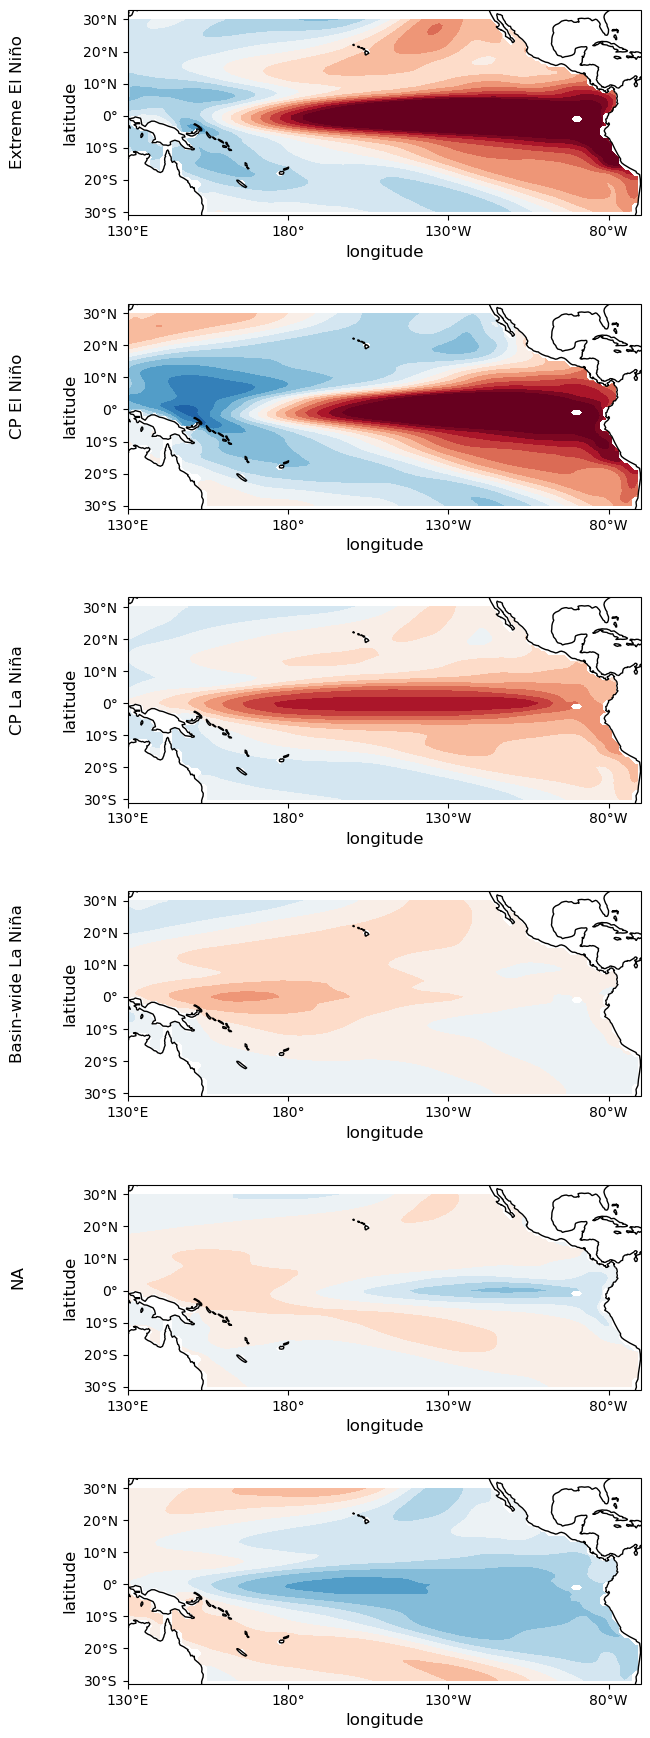

In [54]:
reload(gpl)
#storer = pcgmm_storer[projection]
n_clusters = 6 
#np.max([
#    storer['gmm_scan']['k'].unique()[np.argmin([storer['gmm_scan'].loc[storer['gmm_scan']['k']==k]['bic'].mean() for k in storer['gmm_scan']['k'].unique()])]
#    for storer in pcgmm_storer.values()
#])
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',"NA", ""]
nrows, ncols = (n_clusters, len(eof_projections))
axs = np.empty((nrows, ncols), dtype=object)
fig = plt.figure(figsize=(ncols*6, nrows*3.))
height_ratio = [1]*nrows
height_ratio[1] = 1
clevs = np.arange(-2.0,2.25,0.25)
cmap = 'RdBu_r'
gs = gridspec.GridSpec(nrows, ncols,
                       height_ratios=height_ratio)

proj = ctp.crs.PlateCarree(central_longitude=180)
plparam = {'ssta': dict(vmin=-2, vmax=2, step=0.1, cmap='RdBu_r', centercolor="#ffffff"),
           'ssha': dict(vmin=-.15, vmax=.15, step=0.025,cmap='RdGy_r', centercolor="#ffffff")}
titles = ['piControl','6ka']

#mean = [eofs_pi_map, eofs_mh_map]
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    storer = pcgmm_storer[projection]
    idx = 0 #n + 1  

    # Plot GMM means
    correct_ = correct[i]
    means = PC_pi.inverse_transform(correct_, newdim='mu')
    #means = mean[i]
    
    if 'normalizer' in ds_selected_mh['ssta'].attrs.keys():
        means = ds_selected_mh['ssta'].attrs['normalizer'].inverse_transform(means['ssta'])
    for n, k in enumerate(gmm_order):
        mu = means.sel(mu=k)
        idx = n 
        ax = fig.add_subplot(gs[idx,i], projection=proj)
        axs[idx,i] = ax
        #im = gpl.plot_map(mu['ssta'], ax=ax, #central_longitude=180, 
        #                  bar='discrete', add_bar=False, **plparam['ssta'])
        #im['gl'].top_labels = False 
        da_reg = mu["ssta"]
        da_reg = da_reg.sortby("lat")
        lon_test = ((da_reg["lon"]+ 360) % 360)
        da_reg = da_reg.assign_coords(lon=lon_test)#da_reg.sortby("lon")
        #cs = da_reg.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
        #                            cmap=cmap, add_colorbar=False, vmin=-2.5, vmax=2.5) 
        #cs = da_reg.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
        #                          cmap=cmap, add_colorbar=False, levels=clevs, extend="both")
        #data = da_reg
        # Add the cyclic point
        #data,lons = add_cyclic_point(data,coord=da_reg['lon'])
        cs = ax.contourf(da_reg.lon, da_reg.lat, da_reg, transform=ccrs.PlateCarree(),
                                  cmap=cmap, add_colorbar=False, levels=clevs, extend="both")
        ax.set_title("")
        ax.set_extent([130, 290, -31, 33], crs=ccrs.PlateCarree()) 
        if i == 0:
            ax.text(-0.20, 0.55, class_names[n], va='bottom', ha='center',
                rotation='vertical', rotation_mode='anchor',
                transform=ax.transAxes)
        # Define the xticks for longtitude 
        ax.set_xticks(np.arange(130,291,50),crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        ax.tick_params(labelsize=10)

        # Define ytick for latitude
        ax.set_yticks(np.arange(-30,31,10),crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.coastlines()

    # Title
    axs[0,i].set_title(titles[i], size=16)
    

# Shared colorbar
cbar_ax = fig.add_axes([0.2, -0.02, 0.6, 0.01])
cbar = plt.colorbar(cs, orientation='horizontal', shrink=0.7,
                    cax=cbar_ax, extend='both')
cbar.set_label(f"SSTA[K]", size=12)
    
# Enumerate plots
labels = ["a", "b", "c", "d", "e", "f", "g", "h"]
for i in np.arange(0,4):
    for j in np.arange(0,2):
        axs[i,j].text(-50, 35, labels[2*i+j], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
#gpl.enumerate_subplots(axs.flatten(), pos_x=0.01, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/clusters_spatialpatterns_200_SST_f.pdf")

### Check the strongest SSTA points for each type of ENSO

In [ ]:
correct = [gmm.means_, expected_means]
for i, projection in enumerate(eof_projections):
    print(projection)
    
    correct_ = correct[i]
    means = PC_pi.inverse_transform(correct_, newdim='mu')
    for n, k in enumerate(gmm_order):
        print(k)
        
        mu = means.sel(mu=k)
        sst = mu['ssta']

        # 1. Get the maximum and minimum SST value
        sst_max = sst.max()
        sst_min = sst.min()

        # 2. Get the location (lat, lon) of the maximum SST
        max_idx = sst.argmax(dim=["lat", "lon"])
        min_idx = sst.argmin(dim=["lat", "lon"])
        max_loc = sst.isel(lat=max_idx["lat"], lon=max_idx["lon"])
        min_loc = sst.isel(lat=min_idx["lat"], lon=min_idx["lon"])

        # Print the result
        print("Maximum SSTA:", float(sst_max.values))
        print("Location (lat, lon):", float(max_loc['lat'].values), float(max_loc['lon'].values))
        print("Minimum SSTA:", float(sst_min.values))
        print("Location (lat, lon):", float(min_loc['lat'].values), float(min_loc['lon'].values))

### 12. Decadal Variability

In [ ]:
# Load weights
weight_month_mean = p_c_given_x_da
weight_month_mean_mh = p_c_given_x_da_mh
gmm_order = weight_month_mean.attrs['gmm_sort']
gmm_order_mh = weight_month_mean_mh.attrs['gmm_sort']

In [ ]:
nino34_concat_pi = sst_pi_anom_masked
nino34_selected_pi = nino34_concat_pi.sel(lon=slice(-170, -120), lat=slice(-5,5))
nino34_selected_pi

nino34_concat_mh = sst_mh_anom_masked
nino34_selected_mh = nino34_concat_mh.sel(lon=slice(-170, -120), lat=slice(-5,5))
nino34_selected_mh

In [ ]:
nino34_mean = nino34_selected_pi["ssta"].mean(dim=["lat","lon"])
nino34_mean_mh = nino34_selected_mh["ssta"].mean(dim=["lat","lon"])

### 13. Analyze clusters based on Nino3.4

In [ ]:
weights34 = weight_month_mean
weights34_ = weight_month_mean_mh
nino34 = nino34_mean #nino_indices['nino34']
nino34_ = nino34_mean_mh #nino_indices_['nino34']

In [ ]:
# Make sure weights and nino-indices are on the same time points
#nino34 = nino34.rolling(time=3, center=True).mean()
tmax = nino34['time'].max() if nino34['time'].max() < weights34['time'].max() else weights34['time'].max()
tmin = nino34['time'].min() if nino34['time'].min() > weights34['time'].min() else weights34['time'].min()
nino34 = nino34.sel(time=slice(tmin.data, tmax.data))
weights34 = weights34.sel(time=slice(tmin.data, tmax.data))
weights34['time'] = np.array(weights34['time'].data)#, dtype='datetime64[M]')
nino34['time'] = np.array(nino34['time'].data)#, dtype='datetime64[M]')
nino34 = nino34.sel(time=weights34['time'])

#nino34_ = nino34_.rolling(time=3, center=True).mean()
tmax_ = nino34_['time'].max() if nino34_['time'].max() < weights34_['time'].max() else weights34_['time'].max()
tmin_ = nino34_['time'].min() if nino34_['time'].min() > weights34_['time'].min() else weights34_['time'].min()
nino34_ = nino34_.sel(time=slice(tmin_.data, tmax_.data))
weights34_ = weights34_.sel(time=slice(tmin_.data, tmax_.data))
weights34_['time'] = np.array(weights34_['time'].data)#, dtype='datetime64[M]')
nino34_['time'] = np.array(nino34_['time'].data)#, dtype='datetime64[M]')
nino34_ = nino34_.sel(time=weights34_['time'])

In [ ]:
#time object

parsed_time = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34['time'].values])
timearray = np.array(parsed_time, dtype='object')
parsed_time_ = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_['time'].values])
timearray_ = np.array(parsed_time_, dtype='object')

# Convert string dates to datetime objects
date_parsed = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray]
date_parsed_ = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_]

nino34["time"] = date_parsed
weights34["time"] = date_parsed
nino34_["time"] = date_parsed_
weights34_["time"] = date_parsed_

# for nino34_mean
parsed_time_mean = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_mean['time'].values])
timearray_mean = np.array(parsed_time_mean, dtype='object')
parsed_time_mean_mh = np.array([t.strftime('%Y-%m-%d %H:%M:%S') for t in nino34_mean_mh['time'].values])
timearray_mean_mh = np.array(parsed_time_mean_mh, dtype='object')
# Convert string dates to datetime objects
date_parsed_mean = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_mean]
date_parsed_mean_mh = [datetime.strptime(date, "%Y-%m-%d %H:%M:%S") for date in timearray_mean_mh]
nino34_mean["time"] = date_parsed_mean
nino34_mean_mh["time"] = date_parsed_mean_mh

In [ ]:
# Average weights over Dec-Jan-Feb

# Add 1300 years by modifying the year part
date_modified = [d.replace(year=d.year + 1300) for d in date_parsed]
weight_date_data = weights34
weight_date_data["time"] = date_modified
date_modified_ = [d.replace(year=d.year + 1300) for d in date_parsed_]
weight_date_data_mh = weights34_
weight_date_data_mh["time"] = date_modified_
nino34["time"] = date_modified
nino34_["time"] = date_modified_

# for raw nino34_mean time series
date_modified_mean = [d.replace(year=d.year + 1300) for d in date_parsed_mean]
date_modified_mean_mh = [d.replace(year=d.year + 1300) for d in date_parsed_mean_mh]
nino34_mean["time"] = date_modified_mean
nino34_mean_mh["time"] = date_modified_mean_mh

### Decadal Occurance & variability

In [ ]:
# Average weights over Dec-Jan-Feb

weight_events = []
for y in np.unique(weight_date_data.time.dt.year):
    event = weight_date_data.sel(time=slice(f"{y}-12-01", f"{y+1}-02-28")).mean(dim='time')
    event['time'] = np.datetime64(f"{y}-12-01", 'M')
    weight_events.append(
        event
    )
weight_events = xr.concat(weight_events, dim='time')

weight_events_ = []
for y in np.unique(weight_date_data_mh.time.dt.year):
    event_ = weight_date_data_mh.sel(time=slice(f"{y}-12-01", f"{y+1}-02-28")).mean(dim='time')
    event_['time'] = np.datetime64(f"{y}-12-01", 'M')
    weight_events_.append(
        event_
    )
weight_events_ = xr.concat(weight_events_, dim='time')

In [ ]:
occurance_arr = []
times = []
occurance_arr_ = []
times_ = []
    #for i in range(window_size-1, len(da['time'])):
        # Select window
chunk = weight_date_data #weight_events#.isel(time=slice(i-window_size+1, i+1))
chunk_ = weight_date_data_mh #weight_events_

# Compute covariance
occ = chunk.sum(dim='time')
occurance_arr.append(occ)
times.append(chunk['time'].data)
occurances = occurance_arr[0]
occ_ = chunk_.sum(dim='time')
occurance_arr_.append(occ_)
times_.append(chunk_['time'].data)
occurances_ = occurance_arr_[0]

stacked_occurances = []
for k in gmm_order:
    stacked_occurances.append(occurance_arr[0].isel(classes=k))#/occurance_arr[0].sum(dim='classes'))
stacked_occurances_ = []
for k in gmm_order_mh:
    stacked_occurances_.append(occurance_arr_[0].isel(classes=k))#/occurance_arr_[0].sum(dim='classes'))

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',]
clrs = gmclrs[:len(gmm_order)]
# Decadel variability
bottom = np.zeros_like(stacked_occurances[0])
bottom_ = np.zeros_like(stacked_occurances_[0])
for i, stack in enumerate(stacked_occurances):
    ax.bar(0.25, stack, bottom=bottom, width=0.25, color=gmclrs[i], label=class_names[i])
    bottom += stack.data
ax.legend(loc='best', ncol=1, bbox_to_anchor=(0.48, 0.75, .52, 0.1), 
           fontsize=8, mode='expand')
for i, stack in enumerate(stacked_occurances_):
    ax.bar(0.75, stack, bottom=bottom_, width=0.25, color=gmclrs[i], label=class_names[i])
    bottom_ += stack.data
ax.set_xticks([0.25,0.75])
ax.set_xticklabels(['piControl','6ka'])
ax.set_ylabel("Occurrences")

#axs[3].axvline(np.datetime64('1970-01-01'), ls=':', color='k')
#plt.savefig("/home/gsato/latgmm/figures/Occurrences_200_no_34.pdf")

### Decadal variability

In [ ]:
def rolling_window_covariance(da: xr.DataArray):
    covs = []
    times = []
    #for i in range(window_size-1, len(da['time'])):
        # Select window
    chunk = da
    # Compute covariance
    cov = np.cov(chunk.data[~np.isnan(chunk.data)])
    covs.append(cov)
    times.append(chunk['time'].data)
    
    return np.array(covs), np.array(times)


# Weights and Nino3.4 should span same time period
#nino34 = nino34.sel(time=slice("1855-12-01", None))
#weights = weights.sel(time=slice("1855-12-01", None)) 

# Weighted Nino3.4
nino34_k = []
for k in weights34['classes']:
    nino34_k.append(nino34 * weights34.sel(classes=k))
nino34_k = xr.concat(nino34_k, dim=pd.Index(weights34['classes'].data, name='classes'))

nino34_var, times = rolling_window_covariance(nino34)
nino34_k_cov = []
for i in np.arange(1,6):
    nino34_cov, times = rolling_window_covariance(nino34_k.sel(classes=i)) 
    nino34_k_cov.append(nino34_cov)
###    
nino34_k_ = []
for k in weights34_['classes']:
    nino34_k_.append(nino34_ * weights34_.sel(classes=k))
nino34_k_ = xr.concat(nino34_k_, dim=pd.Index(weights34_['classes'].data, name='classes'))

nino34_var_, times_ = rolling_window_covariance(nino34_)
nino34_k_cov_ = []
for i in range(1,6):
    nino34_cov_, times_ = rolling_window_covariance(nino34_k_.sel(classes=i)) 
    nino34_k_cov_.append(nino34_cov_)

In [ ]:
stacked_lines = [(nino34_k_cov[i] / nino34_var) for i in gmm_order]
stacked_lines_ = [(nino34_k_cov_[i] / nino34_var_) for i in gmm_order_mh]

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator,MultipleLocator,AutoMinorLocator
import datetime

labels = [rf"k={k}" for k in gmm_order]
labels_abc = ["a", "b", "c", "d", "e", "f"]
#labels.append("cov")
fig, axs = plt.subplots(2, 3, 
                        width_ratios=[3,1,1],
                        figsize=(10, 6),)
                        #sharey=True)
axs = axs.flatten()

#nrows, ncols = (2, 2)
#fig = plt.figure(figsize=(9, nrows*2.))
#gs = gridspec.GridSpec(nrows, ncols, width_ratios=[3,1], height_ratios=[2,1,2])
#axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]
#axs.append(fig.add_subplot(gs[1,0]))#, sharex=axs[0]))
#axs.append(fig.add_subplot(gs[2,0]))#, sharex=axs[0]))
#axs.append(fig.add_subplot(gs[1:,1]))

# Nino34 time-series and hisplot
#im, bins, _ = axs[1].hist(nino34.data, bins='auto', density=True, orientation='horizontal',
 #                         histtype='bar', color='k', alpha=.5)#, label="piControl")
#im_, bins_, _ = axs[3].hist(nino34_.data, bins='auto', density=True, orientation='horizontal',
 #                         histtype='bar', color='k', alpha=.5)#, label="6ka")
bins=5
    
for i, k in enumerate(gmm_order):
    n34_k = nino34 * weights34.sel(classes=k+1)
    idx_nonzero = np.where(weights34.sel(classes=k+1).data > 0.5)[0]
    n34_k = n34_k[idx_nonzero]
    axs[0].bar(n34_k['time'].data, height=n34_k.data, width=4e2,
                   color=gmclrs[i], alpha=.8)
    axs[0].plot(date_modified_mean,#nino_indices["nino34"]["time"], 
                nino34_mean, linewidth=0.2) #nino_indices["nino34"]#.rolling(time=3, center=True).mean()
    axs[0].set_title("piControl")
    axs[1].sharey(axs[0])
    axs[1].hist(n34_k.data, bins=bins, density=False, orientation='horizontal',
                histtype='step', color=gmclrs[i], linewidth=1.5, #alpha=.4,
                label="_nolegend_")#class_names[i])
#                label=r'$p(c_{k}|z_t) \cdot y$'.replace('k', str(k+1)))
    axs[1].set_title('piControl')

for i, k in enumerate(gmm_order_mh):
    n34_k_ = nino34_ * weights34_.sel(classes=k+1)
    idx_nonzero_ = np.where(weights34_.sel(classes=k+1).data > 0.5)[0]
    n34_k_ = n34_k_[idx_nonzero_]
    axs[3].sharex(axs[0])
    axs[3].bar(n34_k_["time"].data, height=n34_k_.data, width=4e2,
                   color=gmclrs[i], alpha=.8)#, label=rf'$p(c={k}|z_t) \cdot y$')
    axs[3].plot(date_modified_mean_mh,#nino_indices_["nino34"]["time"], 
                nino34_mean_mh, linewidth=0.2) #nino_indices_["nino34"]#.rolling(time=3, center=True).mean()
    axs[3].set_title('6ka')
    axs[4].sharey(axs[3])
    axs[4].hist(n34_k_.data, bins=bins, density=False, orientation='horizontal',
                histtype='step', color=gmclrs[i], linewidth=1.5, #alpha=.4,
               )#label=class_names[i])
    axs[4].set_title('6ka')

for n in range(2):
    for i in np.arange(-5,5):
        axs[3*n].axhline(y=-0.5*i, c="black", linewidth=0.4, alpha=0.7, linestyle="--")
    axs[3*n].set_xlabel("years")
    axs[3*n].set_ylabel("Niño3.4")
    #axs[2*n].xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))
    #axs[3*n].set_xticklabels(["0", "$1\pi$", "$2\pi$", "$3\pi$", "$4\pi$"])
    axs[3*n].tick_params(axis='x', rotation=0, labelsize=11)
    axs[3*n].set_ylim(-3.5,4)
    axs[3*n].set_yticks(ticks=np.arange(-3,3.1,1))
    axs[3*n].yaxis.set_minor_locator(ticker.AutoMinorLocator(n=2))
    axs[3*n].tick_params(axis='y', rotation=0, labelsize=12)
    axs[3*n+1].set_xlabel("The number of ENSO events")
    axs[3*n+1].set_ylabel("Niño3.4")
    axs[3*n+1].set_xticks(np.arange(0,101,20))
    axs[3*n+1].set_xlim(0,100)
    axs[3*n+1].tick_params(axis='y', rotation=0, labelsize=12)
    axs[3*n+1].yaxis.set_tick_params(labelleft=True) 
    #axs[2*n+1].legend(bbox_to_anchor=(1., .1, .6, 1.), loc="lower left", ncol=1)
    
# Suppose your data has a datetime index
time = np.array(date_modified_mean)#.values   # or your own time array
time_ = np.array(date_modified_mean_mh)
n_ticks = 9  # total ticks (including first and last)

# Select indices for evenly spaced ticks
#tick_idx = np.linspace(84, len(time)-12, n_ticks, dtype=int)#
#tick_locs = time[tick_idx]
#tick_idx_ = np.linspace(0, len(time_)-12, n_ticks, dtype=int)
#tick_locs_ = time[tick_idx_]
#axs[0].set_xticks(tick_locs)
xticks = [datetime.datetime(2000, 1, 1, 0, 0), datetime.datetime(2040, 1, 1, 0, 0), 
          datetime.datetime(2080, 1, 1, 0, 0), datetime.datetime(2120, 1, 1, 0, 0),
          datetime.datetime(2160, 1, 1, 0, 0), datetime.datetime(2200, 1, 1, 0, 0)]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(["0000", "0040", "0080", "0120", "0160", "0200"])
import matplotlib.gridspec as gridspec

clrs = gmclrs[:len(gmm_order)]
clrs.append('lightgrey')

# occurrence 
class_names = ['Extreme El Niño', 'CP El Niño', 'CP La Niña', 'Basin-wide La Niña',]
clrs = gmclrs[:len(gmm_order)]
# Decadel variability
bottom = np.zeros_like(stacked_occurances[0])
bottom_ = np.zeros_like(stacked_occurances_[0])
for i, stack in enumerate(stacked_occurances):
    axs[2].bar(0.25, stack, bottom=bottom, width=0.25, color=gmclrs[i])#, label=class_names[i])
    bottom += stack.data
#axs[2].legend(loc='best', ncol=1, bbox_to_anchor=(0.48, 0.75, .52, 0.1), 
#           fontsize=8, mode='expand')
for i, stack in enumerate(stacked_occurances_):
    axs[2].bar(0.75, stack, bottom=bottom_, width=0.25, color=gmclrs[i])#, label=class_names[i])
    bottom_ += stack.data
axs[2].set_xticks([0.25,0.75])
axs[2].set_xticklabels(['piControl','6ka'])
axs[2].set_ylabel("Occurrences (month)")
axs[2].set_title('Occurrences', fontsize=10)

# Decadel variability
bottom = np.zeros_like(stacked_lines[0]*nino34_var)#nino34_k_cov[0]
bottom_ = np.zeros_like(stacked_lines_[0]*nino34_var_)#stacked_lines_[0]
for i, stack in enumerate(stacked_lines):#nino34_k_cov
    axs[5].bar(0.25, stack*nino34_var, bottom=bottom, width=0.25, color=clrs[i], label=class_names[i])
    bottom += (stack.data)*nino34_var
#axs[5].legend(loc='best', ncol=1, bbox_to_anchor=(0.55, 0.90, 0.45, 0.1), fontsize=8, mode='expand')
for i, stack_ in enumerate(stacked_lines_):#_
    axs[5].bar(0.75, stack_*nino34_var_, bottom=bottom_, width=0.25, color=clrs[i], label="_nolegend_")#class_names[i])
    bottom_ += (stack_.data)*nino34_var_
axs[5].set_ylim(0,3.0)    
axs[5].set_ylabel(r"Variances")
axs[5].set_xticks([0.25,0.75])
axs[5].set_xticklabels(['piControl','6ka'])
axs[5].set_title('Variances\n   [4 ENSO categories]', fontsize=10)
   
fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.07, 0.97, .9, 0.1), 
           fontsize=12, mode='expand')
for i in np.arange(0,6):
    if i in [0, 3]:
        axs[i].text(datetime.datetime(1990, 12, 1, 0, 0), 4.2, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    elif i == 2:
        axs[i].text(0.075, 500, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    elif i == 5:
        axs[i].text(0.075, 3.1, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
    else:
        axs[i].text(0, 4.2, labels_abc[i], #transform=axs[i, j].transAxes,
                       fontsize=12, fontweight='bold')
#gpl.enumerate_subplots(axs, pos_x=0.00, pos_y=1.05, fontsize=12)
#plt.savefig("/home/gsato/latgmm/figures/clusters_timeseries_variances_200_SST.pdf")

In [ ]:
# total variances
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
variance = nino34_var#.sel(time=years, method='nearest')
variance_ = nino34_var_
#axs[2].plot(nino34_var['time'], nino34_var, color='darkgreen',
#           label=r'$\sigma_{30y}$ (Nino3.4)')
#axs[2].fill_between(nino34_var['time'], np.zeros(len(nino34_var['time'])), nino34_var, color='darkgreen', alpha=.5)
axs.bar(0.25, height=variance,  color='gray', edgecolor='gray', alpha=.5, width=0.25)
axs.bar(0.75, height=variance_,  color='darkgreen', edgecolor='darkgreen', alpha=.5, width=0.25)
axs.set_ylim(0,2.5)
axs.set_ylabel(r"Totla Variances")
axs.set_xticks([0.25,0.75])
axs.set_xticklabels(['piControl','6ka'])
axs.set_title('Variances [total]', fontsize=12)
plt.savefig("/home/gsato/latgmm/figures/clusters_total_variances_200_SST_no_34.pdf")